# Web Scraping

Lots of great data is available online, but available through inconveniently formatted web pages. When this is the case, sometimes you can simply copy and paste the data into a .csv file and go on with your life. But if there are many records to parse and combine into a dataset, that might be impossible. Can we automate the collection of data from online sources?

This is called web scraping. Broadly speaking: Web scraping is legal, but what you plan to do with the results of your scraping might not be. In general, most sites do not want you to scrape them at this point, but there is not really a way to stop you if you are sufficiently motivated. Be careful to use server resources respectfully (not too many requests per unit time), think seriously about privacy concerns, and be careful who you share your work with and how it is used.

We'll be scraping data about used cars in Charlottesville from Craigslist, particularly this page: https://charlottesville.craigslist.org/search/cta?purveyor=owner#search=1~gallery~0~0 

We'll use the `requests` package to get web pages off the Internet and into Python. Again, we'll use a header with a user-agent that masks our true identity so that we're not rejected by the server. This particular url points to the car listings for Craigslist in Charlottesville. To use requests, you pass a `url` for the page you want and a `header` that controls how you appear to the server to `requests.get`:

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import requests # Page requests

header = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:124.0) Gecko/20100101 Firefox/124.0'} # How we wish to appear to CL
url = 'https://charlottesville.craigslist.org/search/cta?purveyor=owner#search=1~gallery~0~0' # The page we want to scrape
raw = requests.get(url,headers=header) # Get page

Now that we have that particular page available locally, we want to **parse** it and get results from it. To do that, we can use a package called `beautifulSoup` or `bs4`.

What does `beautifulSoup` do for us? Let's go to the web page of interest. You probably see something like this:

![Listings](./src/craigslist.png "Craigslist")

But if you "view page source" -- which is CTRL+U -- in Chrome, you see what the computer sees:

![Listings](./src/craigslist_source.png "Craigslist")

Since your web browser needs lots of instructions about how to render the text, pictures, and other content on your web page, there are a lot of clues about where the data live and how to extricate them from a page. These clues are called **tags**. If you wander the source for the search page on cars, you see a particular `class = "cl-static-search-result"` term appear attached to each listing:

![Listings](./src/listing.png "Craigslist")

This structure can be exploited to search the page for information. This kind of detective work -- looking at the page source, finding the interesting tags, and then searching the page with `beautifulSoup` -- is the basic job of web scraping.

What I do is look at the rendered page, find the text I want and copy it, then search for that text in the HTML code that the computer sees. When I find the text I want, I look for the tag nearby. Here, it's `cl-static-search-result`: That's what I'll want beautifulSoup to search for.

The following code chunk takes the raw content from `requests` and turns it into a beautifulSoup object, which can search the page and return results for us:

In [4]:
from bs4 import BeautifulSoup as soup # HTML parser
bsObj = soup(raw.content,'html.parser') # Parse the html
listings = bsObj.find_all(class_="cl-static-search-result") # Find all listings of the kind we want

Why is the argument `class_` and not just `class`? The word `class` is a reserved keyword for Python, and cannot be used by anyone else, similar to `True` and `False`. But since we want the `class = "cl-static-search-result"` terms, we need to use the `class_` argument to the `.find_all` method.

The `.find_all` function dredges the entire page and finds all the instances of `class = "cl-static-search-result"`, resulting in a list of entries. We can then parse the entries.

Parsing the entries can be a challenge! We have to go back to what a listing looks like, and look at the tags within the listing. They're typically `div` tags with a `class` like price or location. You then have to experiment a bit with `.find` and the HTML to make sure you're getting the information you want. For each listing, the `.find` method to search within the listing record for specific information, but it's typically still wrapped in the tag. To get the real information we want, we can then use `.get_text()`. I end up using a code chunk to experiment and play with a record to make sure I'm getting as close to what I want as possible.

In the code below, two more things happen. You don't need to do them in your work, but they're helpful to know about.

First, I would like to get the brand of the car from the post title, if possible. To do this, I split the title into words using `title.split()`, and then I use a list comprehension to look over every word in the title and check whether it appears in the `brands` list.

Second, I would like to get the year the car was built, if possible, so I can determine the vehicle's age. To do this, I use a thing called **regular expressions** that provides a language for expressing patterns. Do I remember how to do this off the top of my head? No, I read a few pages in a book and looked on StackOverflow for answers. Roughly, in order to express the idea "any year starting with 20xx," you can write `20[0-9][0-9]`, and for "any year starting with 19xx," you can write `19[0-9][0-9]`. The `[0-9]`'s act as wildcards for any digit. This allows me to use the `re` package to find any instances of year-like numbers in the title text, using `re.search(r'20[0-9][0-9]|19[0-9][0-9]', title )`.

This is all nested in a for-loop over the listings, and the data is appended to a list.

In [5]:
import re # Regular expressions

brands = ['honda', 'dodge','toyota','ford','tesla','gmc','jeep','bmw','mitsubishi','mazda',
          'volvo','audi','volkswagen','chevy','chevrolet','acura','kia','subaru','lexus',
          'cadillac','buick','porsche','infiniti']

data = [] # We'll save our listings in this object
for k in range( len(listings) ):
    title = listings[k].find('div',class_='title').get_text().lower()
    price = listings[k].find('div',class_='price').get_text()
    link = listings[k].find(href=True)['href']
    # Get brand from the title string:
    words = title.split()
    hits = [word for word in words if word in brands] # Find brands in the title
    if len(hits) == 0:
        brand = 'missing'
    else:
        brand = hits[0]
    # Get years from title string:
    regex_search = re.search(r'20[0-9][0-9]|19[0-9][0-9]', title ) # Find year references
    if regex_search is None: # If no hits, record year as missing value
        year = np.nan
    else: # If hits, record year as first match
        year = regex_search.group(0)
    #
    data.append({'title':title,'price':price,'year':year,'link':link,'brand':brand})


With the data scraped from Craigslist, we can put it in a dataframe and wrangle it. Of course, price and year come in as text, not numbers, and need to be typecast/coerced:

In [6]:
## Wrangle the data
df = pd.DataFrame.from_dict(data)
df['price'] = df['price'].str.replace('$','')
df['price'] = df['price'].str.replace(',','')
df['price'] = pd.to_numeric(df['price'],errors='coerce')
df['year'] = pd.to_numeric(df['year'],errors='coerce')
df['age'] = 2025-df['year']
print(df.shape)
df.to_csv('./src/craigslist_cville_cars.csv') # Save data in case of a disaster
df.head()

(84, 6)


,title,price,year,link,brand,age
0,2013 vw beetle turbo,6000,2013.0,https://charlottesville.craigslist.org/cto/d/n...,missing,12.0
1,1998 jeep wrangler,6850,1998.0,https://charlottesville.craigslist.org/cto/d/w...,jeep,27.0
2,2016 ford edge,12500,2016.0,https://charlottesville.craigslist.org/cto/d/c...,ford,9.0
3,1997 chevy astro van,2500,1997.0,https://charlottesville.craigslist.org/cto/d/p...,chevy,28.0
4,"2003 honda accord ex for sale – $1,300 obo",1300,2003.0,https://charlottesville.craigslist.org/cto/d/c...,honda,22.0


With the data in and wrangled, we can now do some analysis:

count       84.000000
mean      9635.857143
std      10029.153766
min         14.000000
25%       3500.000000
50%       6000.000000
75%      13624.750000
max      49500.000000
Name: price, dtype: float64


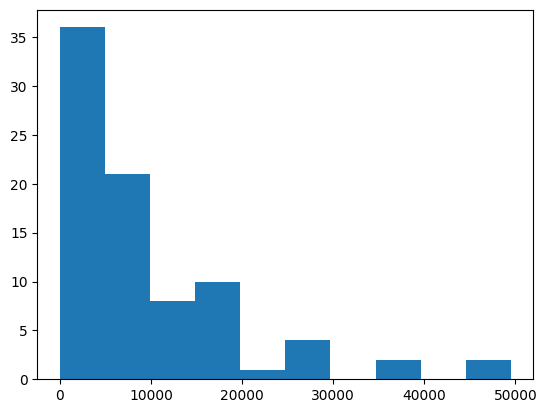

count    78.000000
mean     24.038462
std      16.335319
min       3.000000
25%      14.000000
50%      20.000000
75%      27.000000
max      76.000000
Name: age, dtype: float64


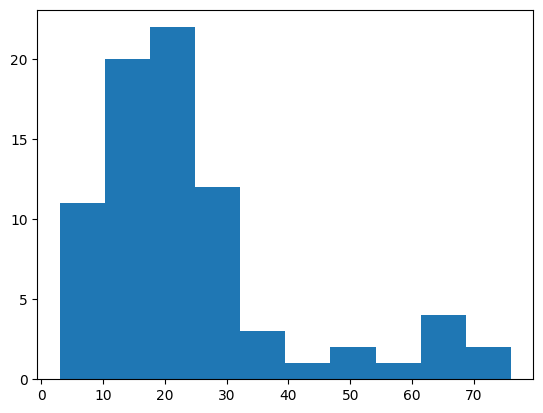

In [7]:
print(df['price'].describe())
df['price'].hist(grid=False)
plt.show()
print(df['age'].describe())
df['age'].hist(grid=False)
plt.show()

In [8]:
# Price by brand:
df.loc[:,['price','brand']].groupby('brand').describe()

price                                                          \
           count          mean           std      min       25%      50%   
brand                                                                      
bmw          5.0  18100.000000  17325.559154   7500.0   8000.00   8500.0   
chevrolet    3.0   9833.333333   6806.859286   4500.0   6000.00   7500.0   
chevy        5.0   6680.000000   7545.661005   1900.0   2500.00   4000.0   
dodge        4.0   9062.250000   3098.494298   6499.0   7249.75   8125.0   
ford        11.0  15000.000000  15606.088555   1500.0   4500.00  10000.0   
gmc          2.0  16000.000000   1414.213562  15000.0  15500.00  16000.0   
honda        5.0   3460.000000   1755.847374   1300.0   2000.00   4000.0   
infiniti     1.0   5000.000000           NaN   5000.0   5000.00   5000.0   
jeep         4.0   3737.500000   3125.000000    900.0   1125.00   3600.0   
kia          1.0   6400.000000           NaN   6400.0   6400.00   6400.0   
lexus        1.0   3500.000000           NaN   3500.0   3500.00   3500.0   
missing     25.0   7742.560000   9063.633405     14.0   2250.00   3500.0   
mitsubishi   1.0   6400.000000           NaN   6400.0   6400.00   6400.0   
porsche      2.0  15000.000000  16263.455967   3500.0   9250.00  15000.0   
subaru       3.0   6283.333333   5386.634695   3000.0   3175.00   3350.0   
tesla        1.0  25000.000000           NaN  25000.0  25000.00  25000.0   
toyota       6.0   9016.500000   4873.158473   4000.0   4850.00   8300.0   
volkswagen   2.0  15750.000000  13081.475452   6500.0  11125.00  15750.0   
volvo        2.0   8100.000000   5091.168825   4500.0   6300.00   8100.0   

                               
                 75%      max  
brand                          
bmw         18500.00  48000.0  
chevrolet   12500.00  17500.0  
chevy        5000.00  20000.0  
dodge        9937.50  13500.0  
ford        16500.00  49500.0  
gmc         16500.00  17000.0  
honda        4500.00   5500.0  
infiniti     5000.00   5000.0  
jeep         6212.50   6850.0  
kia          6400.00   6400.0  
lexus        3500.00   3500.0  
missing      9500.00  37500.0  
mitsubishi   6400.00   6400.0  
porsche     20750.00  26500.0  
subaru       7925.00  12500.0  
tesla       25000.00  25000.0  
toyota      13174.25  15000.0  
volkswagen  20375.00  25000.0  
volvo        9900.00  11700.0

In [9]:
# Age by brand:
df.loc[:,['age','brand']].groupby('brand').describe()

age                                                      
           count       mean        std   min    25%   50%    75%   max
brand                                                                 
bmw          4.0   9.250000   5.619905   3.0   5.25  10.0  14.00  14.0
chevrolet    3.0  14.000000   6.244998   9.0  10.50  12.0  16.50  21.0
chevy        4.0  24.750000   2.753785  22.0  22.75  24.5  26.50  28.0
dodge        4.0  31.750000  17.289207  16.0  22.00  27.5  37.25  56.0
ford        10.0  23.000000  19.894164   5.0  13.75  18.0  25.00  76.0
gmc          2.0  21.000000   4.242641  18.0  19.50  21.0  22.50  24.0
honda        5.0  19.400000   3.781534  13.0  19.00  21.0  22.00  22.0
infiniti     1.0  15.000000        NaN  15.0  15.00  15.0  15.00  15.0
jeep         3.0  22.333333  10.785793  10.0  18.50  27.0  28.50  30.0
kia          1.0  13.000000        NaN  13.0  13.00  13.0  13.00  13.0
lexus        1.0  27.000000        NaN  27.0  27.00  27.0  27.00  27.0
missing     24.0  30.583333  19.827334   7.0  14.75  22.5  43.25  68.0
mitsubishi   1.0  17.000000        NaN  17.0  17.00  17.0  17.00  17.0
porsche      1.0  12.000000        NaN  12.0  12.00  12.0  12.00  12.0
subaru       3.0  16.000000   6.557439  10.0  12.50  15.0  19.00  23.0
tesla        1.0   7.000000        NaN   7.0   7.00   7.0   7.00   7.0
toyota       6.0  22.666667   8.334667  14.0  18.50  20.5  24.00  38.0
volkswagen   2.0  40.000000  43.840620   9.0  24.50  40.0  55.50  71.0
volvo        2.0  22.500000  13.435029  13.0  17.75  22.5  27.25  32.0

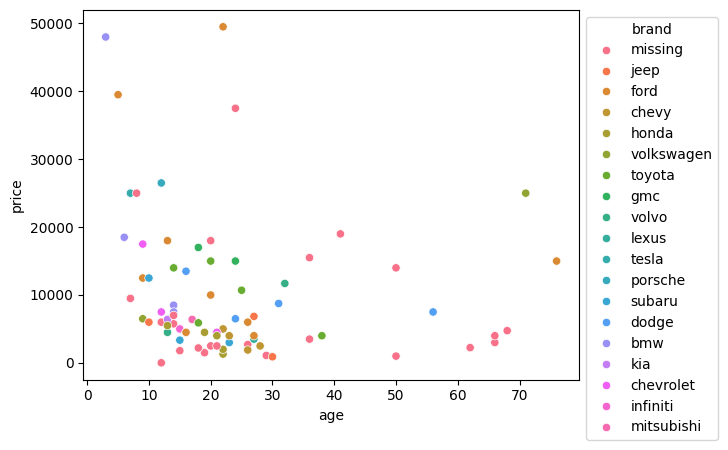

In [10]:
ax = sns.scatterplot(data=df, x='age', y='price',hue='brand')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

           log_price   log_age
log_price   1.314010 -0.161225
log_age    -0.161225  0.398395
           log_price   log_age
log_price   1.000000 -0.221464
log_age    -0.221464  1.000000


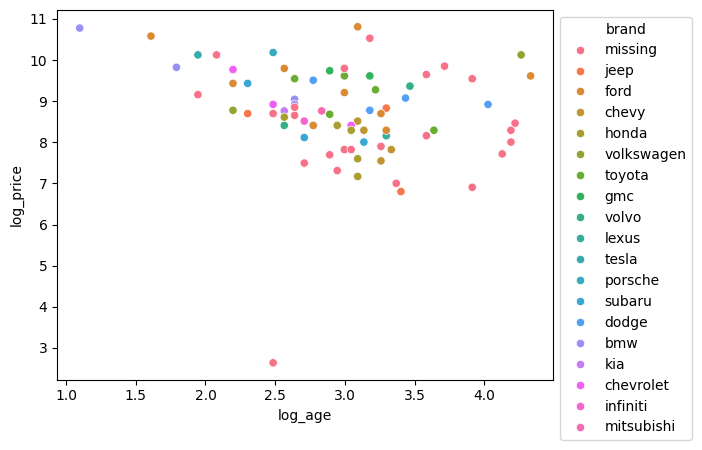

In [11]:
df['log_price'] = np.log(df['price'])
df['log_age'] = np.log(df['age'])

ax = sns.scatterplot(data=df, x='log_age', y='log_price',hue='brand')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

print(df.loc[:,['log_price','log_age']].cov())
print(df.loc[:,['log_price','log_age']].corr())

## The Lab:


1. Pick something else on Craigslist besides used cars: Musical instruments, roommates, antiques, etc. Look at the search page and its source code. Record which fields/data you would like to gather, and what kinds of basic EDA you'd do with it.
2. Get your search results of interest using `requests` and extract data from them using `beautifulSoup`, using code similar to what's above.
3. Wrangle your data into a dataframe and do some basic descriptions and plots. Try to find some interesting relationships or stories to tell about your data.

I chose musical instruments. I would like to gather the title, price, link, location if available. I'd like to get the brand and instrument type from the title.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import requests
from bs4 import BeautifulSoup as soup

header = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:124.0) Gecko/20100101 Firefox/124.0'}
url = 'https://charlottesville.craigslist.org/search/msg?purveyor=owner'
raw = requests.get(url, headers=header)

bsObj = soup(raw.content, 'html.parser')
listings = bsObj.find_all(class_="cl-static-search-result")

brands = ['fender', 'yamaha', 'gibson', 'roland', 'korg', 'casio', 'marshall', 'peavey', 'ibanez', 'epiphone', 'taylor', 'martin']
instruments = ['guitar', 'piano', 'keyboard', 'drum', 'amp', 'bass', 'trumpet', 'violin', 'saxophone', 'clarinet']
data = []

for k in range(len(listings)):
    title = listings[k].find('div', class_='title').get_text().lower()
    price = listings[k].find('div', class_='price').get_text()
    link = listings[k].find(href=True)['href']
    
    words = title.split()
    brand_hits = [word for word in words if word in brands]
    if len(brand_hits) == 0:
        brand = 'missing'
    else:
        brand = brand_hits[0]
        
    type_hits = [word for word in words if word in instruments]
    if len(type_hits) == 0:
        instrument_type = 'missing'
    else:
        instrument_type = type_hits[0]
        
    data.append({'title': title, 'price': price, 'link': link, 'brand': brand, 'instrument_type': instrument_type})

df = pd.DataFrame.from_dict(data)
df['price'] = df['price'].str.replace('$','')
df['price'] = df['price'].str.replace(',','')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df.head()


,title,price,link,brand,instrument_type
0,speakers / mixer / monitors; buy set or indivi...,700,https://charlottesville.craigslist.org/msg/d/w...,missing,missing
1,mackie 32.4 premium 32 channel mixer,795,https://charlottesville.craigslist.org/msg/d/c...,missing,missing
2,studio acoustic egg crate foam,400,https://charlottesville.craigslist.org/msg/d/c...,missing,missing
3,1962 ampeg echo twin et-1,1600,https://charlottesville.craigslist.org/msg/d/c...,missing,missing
4,guitar maintenance accessories assortment,30,https://charlottesville.craigslist.org/msg/d/c...,missing,guitar


count      145.000000
mean       663.627586
std       1360.678711
min          0.000000
25%        100.000000
50%        300.000000
75%        650.000000
max      12345.000000
Name: price, dtype: float64


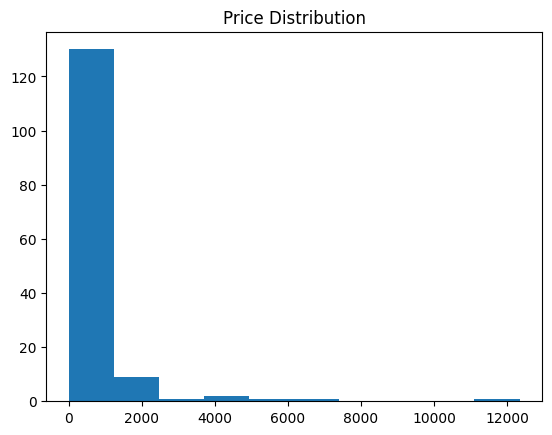

brand
missing     102
fender       15
peavey        8
yamaha        4
epiphone      4
martin        3
gibson        2
ibanez        2
marshall      2
casio         2
taylor        1
Name: count, dtype: int64


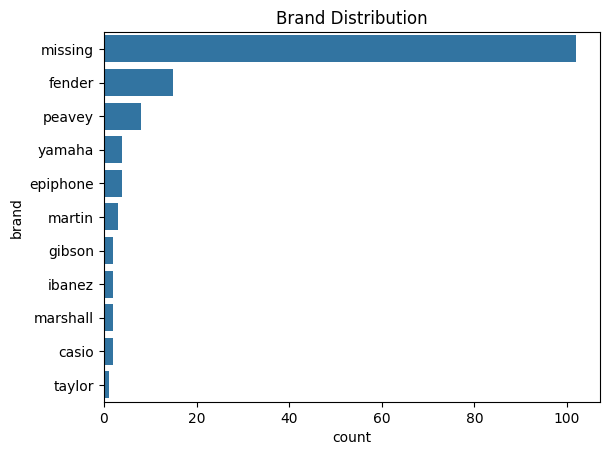

instrument_type
missing     95
guitar      20
drum         8
amp          7
bass         6
piano        5
keyboard     3
violin       1
Name: count, dtype: int64


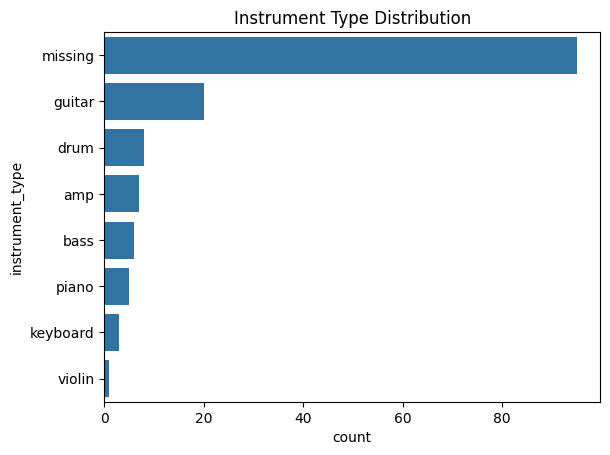

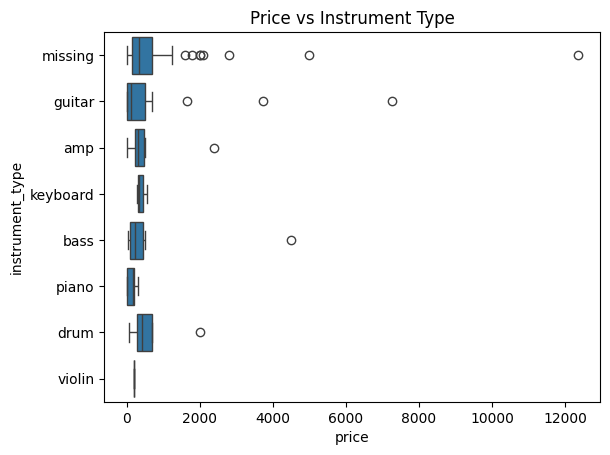

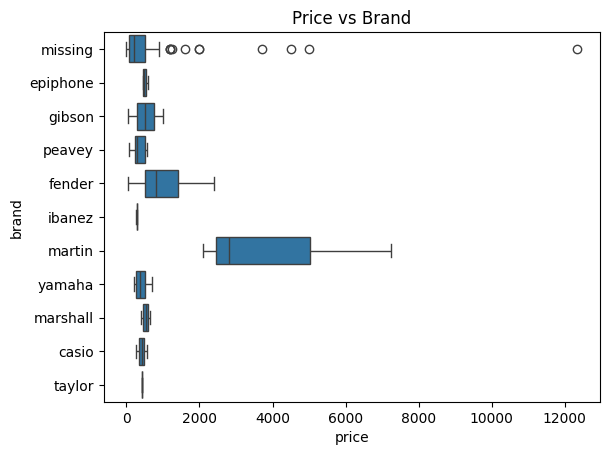

In [18]:
print(df['price'].describe())
df['price'].hist(grid=False)
plt.title('Price Distribution')
plt.show()

print(df['brand'].value_counts())
sns.countplot(data=df, y='brand', order=df['brand'].value_counts().index)
plt.title('Brand Distribution')
plt.show()

print(df['instrument_type'].value_counts())
sns.countplot(data=df, y='instrument_type', order=df['instrument_type'].value_counts().index)
plt.title('Instrument Type Distribution')
plt.show()

sns.boxplot(data=df, x='price', y='instrument_type')
plt.title('Price vs Instrument Type')
plt.show()

sns.boxplot(data=df, x='price', y='brand')
plt.title('Price vs Brand')
plt.show()

From the first graph, you can see that most prices are between 0 and 2000. There are very few instruments more expensive than 2000. Ignoring the missing data, you can see that fender is the most popular brand, and the most common instrument type being sold is guitar. Looking at the third graph, you can see that the price of all instruments are mostly between 0 and 1000 with drums having the most expensive median and guitars the least expensive median. Looking at the fourth graph, you can see that the price of all brands except martin are mostly between 0 and 2000. Martin is significantly more expensive than all other brands as the prices range from around 2000 to 7000.